In [2]:
import pandas as pdy

!kaggle datasets download -d shivamb/netflix-shows
!unzip -q netflix-shows.zip

df_netflix = pd.read_csv('netflix_titles.csv')
print(df_netflix.shape)
print(df_netflix.isnull().sum())
df_netflix.head()

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
netflix-shows.zip: Skipping, found more recently modified local copy (use --force to force download)
replace netflix_titles.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
(8807, 12)
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


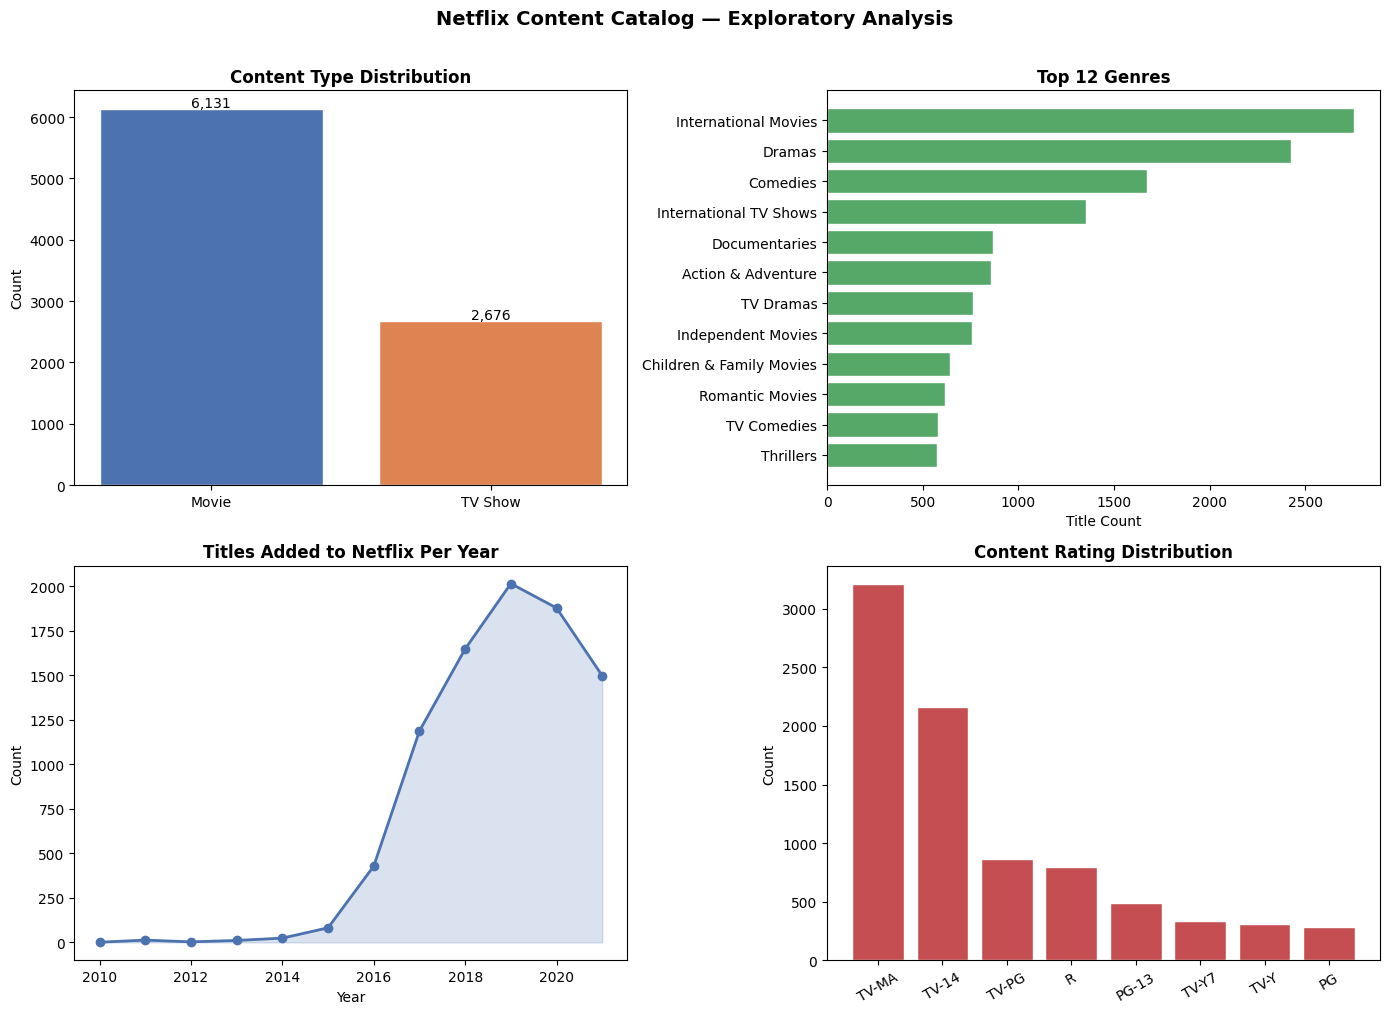

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Movie vs TV Show
type_counts = df_netflix['type'].value_counts()
axes[0,0].bar(type_counts.index, type_counts.values, color=['#4C72B0','#DD8452'], edgecolor='white')
axes[0,0].set_title('Content Type Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0,0].text(i, v + 30, f'{v:,}', ha='center', fontsize=10)

# 2. Top 10 genres (listed_in is comma-separated)
from collections import Counter
genres = df_netflix['listed_in'].dropna().str.split(', ').explode()
genre_counts = Counter(genres).most_common(12)
genre_df = pd.DataFrame(genre_counts, columns=['genre', 'count'])
axes[0,1].barh(genre_df['genre'][::-1], genre_df['count'][::-1], color='#55A868', edgecolor='white')
axes[0,1].set_title('Top 12 Genres', fontweight='bold')
axes[0,1].set_xlabel('Title Count')

# 3. Content added per year
df_netflix['year_added'] = pd.to_datetime(df_netflix['date_added'].str.strip(), errors='coerce').dt.year
year_counts = df_netflix['year_added'].value_counts().sort_index().loc[2010:]
axes[1,0].plot(year_counts.index, year_counts.values, marker='o', color='#4C72B0', linewidth=2)
axes[1,0].fill_between(year_counts.index, year_counts.values, alpha=0.2, color='#4C72B0')
axes[1,0].set_title('Titles Added to Netflix Per Year', fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xlabel('Year')

# 4. Content rating distribution
rating_counts = df_netflix['rating'].value_counts().head(8)
axes[1,1].bar(rating_counts.index, rating_counts.values, color='#C44E52', edgecolor='white')
axes[1,1].set_title('Content Rating Distribution', fontweight='bold')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle('Netflix Content Catalog — Exploratory Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_netflix_eda.png', bbox_inches='tight')
plt.show()

In [4]:
# Simulate what content features would look like per title
df_netflix['is_movie'] = (df_netflix['type'] == 'Movie').astype(int)
df_netflix['release_decade'] = (df_netflix['release_year'] // 10 * 10)

# Top genres as binary features
top_genres = [g for g, _ in genre_counts[:8]]
for genre in top_genres:
    col = genre.lower().replace(' ', '_').replace('&', 'and')
    df_netflix[col] = df_netflix['listed_in'].str.contains(genre, na=False).astype(int)

# Country — is it US content?
df_netflix['is_us'] = df_netflix['country'].fillna('').str.contains('United States').astype(int)

feature_cols = ['is_movie', 'release_decade', 'is_us'] + \
               [g.lower().replace(' ', '_').replace('&', 'and') for g in top_genres]

print("Content feature matrix (sample):")
print(df_netflix[['title'] + feature_cols].head(8).to_string(index=False))
print(f"\nShape: {df_netflix[feature_cols].shape}")

Content feature matrix (sample):
                           title  is_movie  release_decade  is_us  international_movies  dramas  comedies  international_tv_shows  documentaries  action_and_adventure  tv_dramas  independent_movies
            Dick Johnson Is Dead         1            2020      1                     0       0         0                       0              1                     0          0                   0
                   Blood & Water         0            2020      0                     0       1         0                       1              0                     0          1                   0
                       Ganglands         0            2020      0                     0       0         0                       1              0                     1          0                   0
           Jailbirds New Orleans         0            2020      0                     0       0         0                       0              0                     0         